In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

# --- Data Generation (Replace with your actual data loading) ---
def generate_sample_data(num_territories=3, num_products=5, start_date='2021-01-01', end_date='2024-12-31'):
    """Generates sample data for demonstration purposes."""
    date_rng = pd.date_range(start=start_date, end=end_date, freq='D')
    data = []
    for territory in range(num_territories):
        for product in range(num_products):
            for date in date_rng:
                sales_amount = np.random.randint(50, 200) + (np.sin(date.dayofyear * 2 * np.pi / 365) * 50)  # Add some seasonality
                avg_temperature = np.random.randint(10, 30) + (np.sin(date.dayofyear * 2 * np.pi / 365) * 10)
                price = np.random.uniform(10, 50)
                promotion = np.random.choice([0, 1], p=[0.9, 0.1])
                data.append([date, f'Territory_{territory}', f'Product_{product}', sales_amount, avg_temperature, price, promotion])
    df = pd.DataFrame(data, columns=['Date', 'Territory', 'Product', 'Sales_Amount', 'Avg_Temperature', 'Price', 'Promotion'])
    return df

# Generate sample data
#df = generate_sample_data()
df = pd.read_csv('synthetic_sales_data.csv')  # Load your actual data here
df['Date'] = pd.to_datetime(df['Date'])  # Ensure the Date column is in datetime format

# --- Feature Engineering ---
def feature_engineering(df):
    """Engineers features for the models."""
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['Quarter'] = df['Date'].dt.quarter
    df['Temperature_Lag1'] = df.groupby(['Territory', 'Product'])['Avg_Temperature'].shift(1)
    df['Sales_Lag1'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].shift(1)
    df['Sales_Lag7'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].shift(7)
    df['Sales_Lag30'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].shift(30)
    df['Sales_RollingMean7'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].transform(lambda x: x.rolling(window=7).mean())
    df['Sales_RollingStd7'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].transform(lambda x: x.rolling(window=7).std())
    df['Sales_RollingMean30'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].transform(lambda x: x.rolling(window=30).mean())
    df['Sales_RollingStd30'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].transform(lambda x: x.rolling(window=30).std())
    df['Sales_Diff1'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].diff(periods=1)
    df['Sales_Diff7'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].diff(periods=7)
    df['Sales_Diff30'] = df.groupby(['Territory', 'Product'])['Sales_Amount'].diff(periods=30)
    df['Temperature_Diff1'] = df.groupby(['Territory', 'Product'])['Avg_Temperature'].diff(periods=1)
    df['Temperature_Diff7'] = df.groupby(['Territory', 'Product'])['Avg_Temperature'].diff(periods=7)
    df['Temperature_Diff30'] = df.groupby(['Territory', 'Product'])['Avg_Temperature'].diff(periods=30)
    df['Promotion_Lag1'] = df.groupby(['Territory', 'Product'])['Promotion'].shift(1)
    df['Promotion_Lag7'] = df.groupby(['Territory', 'Product'])['Promotion'].shift(7)
    df['Promotion_Lag30'] = df.groupby(['Territory', 'Product'])['Promotion'].shift(30)
    df.fillna(0, inplace=True)
    return df

df = feature_engineering(df)

# --- Data Splitting ---
train_df = df[df['Year'].isin([2021, 2022, 2023])]
test_df = df[df['Year'] == 2024]

# --- SARIMAX Model ---
def train_sarimax(train_data, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)):
    # Create Fourier terms for monthly seasonality
    fourier = CalendarFourier(freq='ME', order=2)  # Monthly seasonality, 2 harmonics
    dp = DeterministicProcess(
        index=train_data.index,
        constant=True,
        order=0,
        seasonal=False,
        additional_terms=[fourier],
        drop=True,
    )
    fourier_terms = dp.in_sample()
    # combine fourier with exogenous variables
    X = pd.concat([fourier_terms, train_data[['Promotion', 'Avg_Temperature']]], axis=1)
    """Trains a SARIMAX model."""
    model = SARIMAX(train_data['Sales_Amount'], exog=X,order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    return model_fit

def evaluate_sarimax(model, test_data):
    """Evaluates the SARIMAX model."""
    # Recreate Fourier terms for the test data
    fourier = CalendarFourier(freq='ME', order=2)
    dp = DeterministicProcess(
        index=test_data.index,
        constant=True,
        order=0,
        seasonal=False,
        additional_terms=[fourier],
        drop=True,
    )
    fourier_terms = dp.in_sample()

    # Combine Fourier terms with other exogenous variables
    exog_test = pd.concat([fourier_terms, test_data[['Promotion', 'Avg_Temperature']]], axis=1)

    predictions = model.predict(start=test_data.index[0], end=test_data.index[-1], exog=exog_test)
    mae = mean_absolute_error(test_data['Sales_Amount'], predictions)
    mase = calculate_mase(test_data['Sales_Amount'], predictions, train_data['Sales_Amount'])
    return mae, mase, predictions

def calculate_mase(actual, forecast, train):
    """Calculates the Mean Absolute Scaled Error (MASE)."""
    mae_naive = np.mean(np.abs(np.diff(train)))
    if mae_naive == 0:
        return np.nan
    return np.mean(np.abs(actual - forecast)) / mae_naive

# --- LightGBM Model ---
def train_lightgbm(train_data, test_data, features):
    """Trains a LightGBM model."""
    X_train, y_train = train_data[features], train_data['Sales_Amount']
    X_test, y_test = test_data[features], test_data['Sales_Amount']

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

    params = {
        'boosting_type': 'gbdt',
        'objective': 'regression',
        'metric': {'l1', 'l2'},
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': 0
    }

    gbm = lgb.train(params,
                    lgb_train,
                    num_boost_round=100,
                    valid_sets=lgb_eval,
                    callbacks=[lgb.early_stopping(stopping_rounds=5)])
    return gbm

def evaluate_lightgbm(model, test_data, features):
    """Evaluates the LightGBM model."""
    predictions = model.predict(test_data[features], num_iteration=model.best_iteration)
    mae = mean_absolute_error(test_data['Sales_Amount'], predictions)
    mase = calculate_mase(test_data['Sales_Amount'], predictions, train_data['Sales_Amount'])
    return mae, mase, predictions

# --- Model Training and Evaluation ---
results = []
for territory in df['Territory'].unique()[:2]:
    for product in df['Product'].unique()[:2]:
        print(f"Training models for Territory: {territory}, Product: {product}")
        train_data = train_df[(train_df['Territory'] == territory) & (train_df['Product'] == product)].set_index('Date').asfreq('D')
        test_data = test_df[(test_df['Territory'] == territory) & (test_df['Product'] == product)].set_index('Date').asfreq('D')

        # SARIMAX
        sarimax_model = train_sarimax(train_data)
        sarimax_mae, sarimax_mase, sarimax_predictions = evaluate_sarimax(sarimax_model, test_data)

        # LightGBM
        features = [col for col in train_data.columns if col not in ['Sales_Amount', 'Year', 'Territory', 'Product']]
        lgbm_model = train_lightgbm(train_data, test_data, features)
        lgbm_mae, lgbm_mase, lgbm_predictions = evaluate_lightgbm(lgbm_model, test_data, features)

        results.append({
            'Territory': territory,
            'Product': product,
            'SARIMAX MAE': sarimax_mae,
            'SARIMAX MASE': sarimax_mase,
            'LightGBM MAE': lgbm_mae,
            'LightGBM MASE': lgbm_mase,
            'SARIMAX Model': sarimax_model,
            'LightGBM Model': lgbm_model,
            'SARIMAX Predictions': sarimax_predictions,
            'LightGBM Predictions': lgbm_predictions,
            'Test Data': test_data
        })


Training models for Territory: Germany, Product: HydraCool Oral Electrolyte
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 4.12781e+06	valid_0's l2: 3.71929e+13
Training models for Territory: Germany, Product: ThermoCough Night Syrup
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 5.00548e+06	valid_0's l2: 6.63477e+13
Training models for Territory: Rio de Janeiro, Product: HydraCool Oral Electrolyte
Training until validation scores don't improve for 5 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 804841	valid_0's l2: 1.82811e+12
Training models for Territory: Rio de Janeiro, Product: ThermoCough Night Syrup
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_

In [2]:
results_df = pd.DataFrame(results)

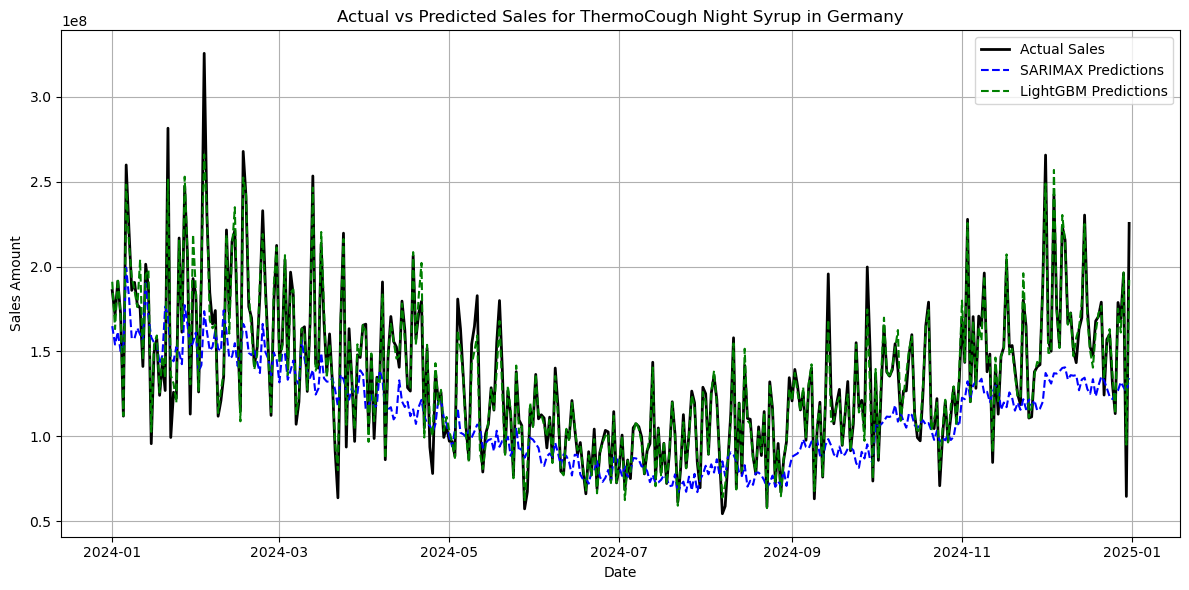

In [8]:
# Select a sample result for plotting
sample_result = results_df.iloc[1]  # Adjust the index to select a specific result
test_data = sample_result['Test Data']
sarimax_predictions = sample_result['SARIMAX Predictions']
lightgbm_predictions = sample_result['LightGBM Predictions']

# Plot the test data and predictions
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Sales_Amount'], label='Actual Sales', color='black', linewidth=2)
plt.plot(sarimax_predictions.index, sarimax_predictions, label='SARIMAX Predictions', color='blue', linestyle='--')
plt.plot(test_data.index, lightgbm_predictions, label='LightGBM Predictions', color='green', linestyle='--')

# Customize the plot
plt.title(f"Actual vs Predicted Sales for {sample_result['Product']} in {sample_result['Territory']}")
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

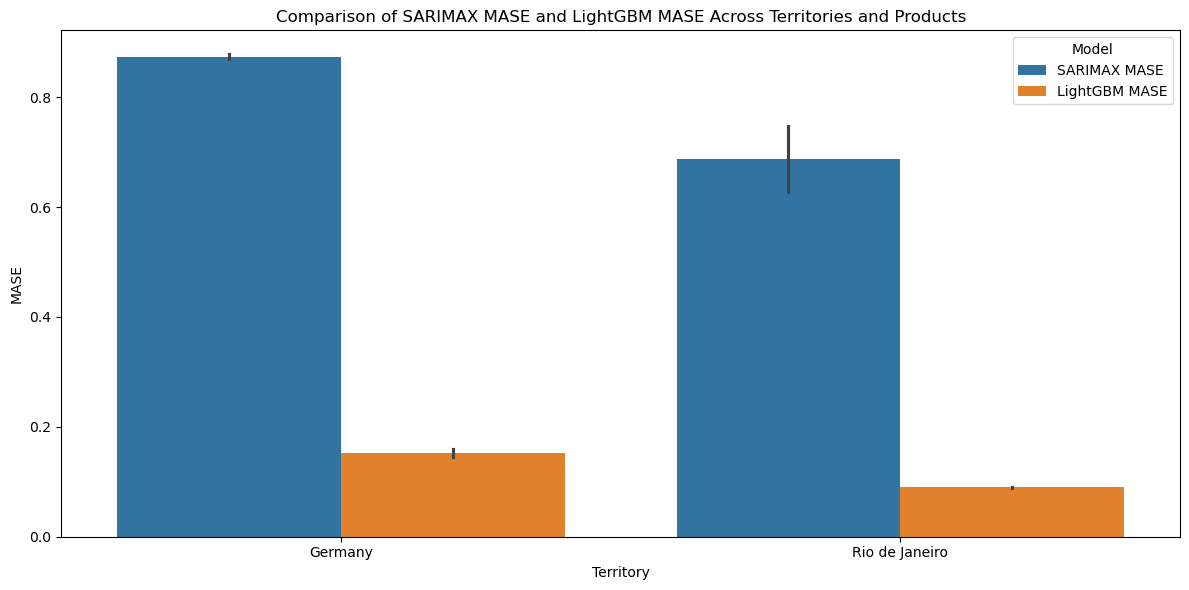

In [4]:
# Comparison of SARIMAX MASE and LightGBM MASE
fig, ax = plt.subplots(figsize=(12, 6))

# Reshape the data for plotting
mase_comparison = results_df.melt(
    id_vars=['Territory', 'Product'],
    value_vars=['SARIMAX MASE', 'LightGBM MASE'],
    var_name='Model',
    value_name='MASE'
)

# Plot the grouped bar chart
sns.barplot(
    x='Territory',
    y='MASE',
    hue='Model',
    data=mase_comparison,
    ax=ax
)

# Customize the plot
ax.set_title('Comparison of SARIMAX MASE and LightGBM MASE Across Territories and Products')
ax.set_ylabel('MASE')
ax.set_xlabel('Territory')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

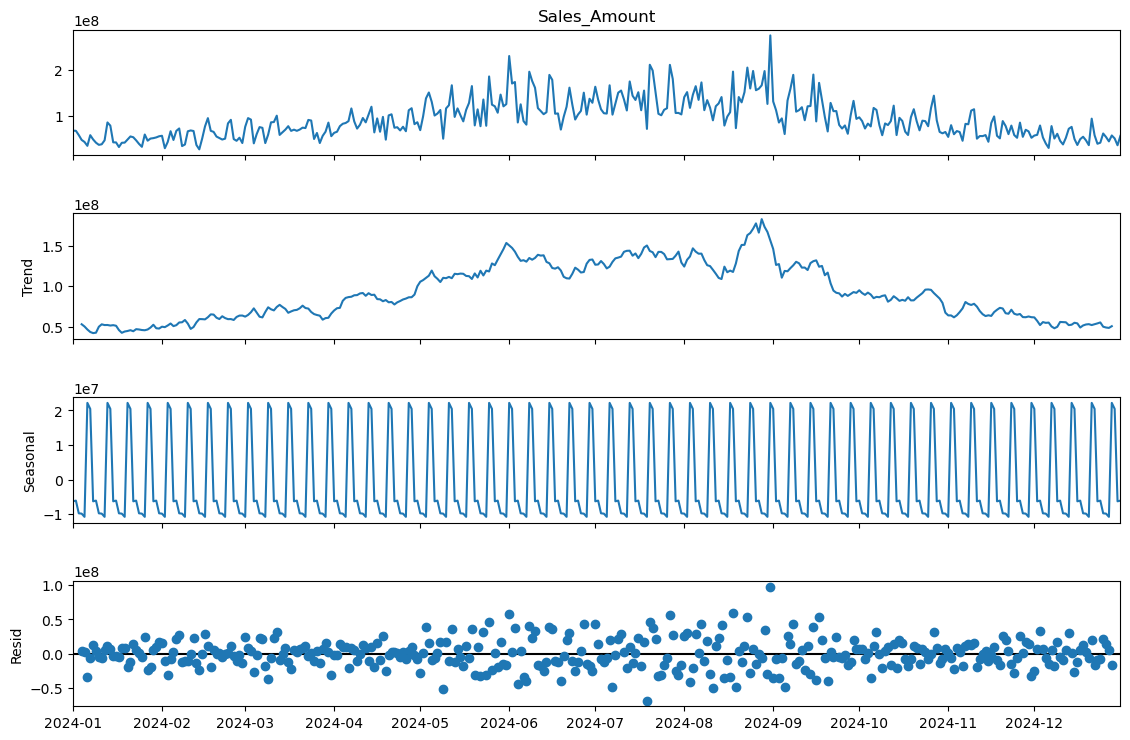

In [5]:

# Seasonality Decomposition for one product in one territory
sample_result = results_df.iloc[0]
sample_test_data = sample_result['Test Data']
decomposition = seasonal_decompose(sample_test_data['Sales_Amount'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


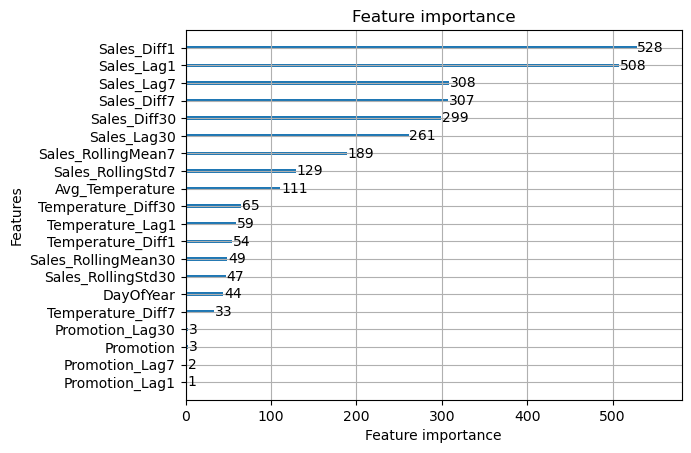

In [6]:

# Feature Importance for LightGBM
sample_lgbm_model = sample_result['LightGBM Model']
lgb.plot_importance(sample_lgbm_model, max_num_features=20)
plt.show()


In [7]:

# --- Model Saving ---
import os

# Create the models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

for index, row in results_df.iterrows():
    with open(f"models/sarimax_model_{row['Territory']}_{row['Product']}.pkl", 'wb') as f:
        pickle.dump(row['SARIMAX Model'], f)
    with open(f"models/lightgbm_model_{row['Territory']}_{row['Product']}.pkl", 'wb') as f:
        pickle.dump(row['LightGBM Model'], f)
